# WSD для киргизского — экспериментальный прогон

Обучение и оценка моделей gloss selection (KyrgyzBERT / mBERT / XLM-R / Kaz-RoBERTa),
полный файнтюнинг и LoRA, несколько seed'ов для доверительных интервалов.

## 1. Подключение проекта

In [1]:
!unzip -q /content/experiments_extended.zip -d /content/experiments

In [2]:
import os

PROJECT = '/content/'

os.chdir(os.path.join(PROJECT, 'experiments'))
print('рабочая папка:', os.getcwd())

рабочая папка: /content/experiments


In [3]:
!pip install -q -r requirements-colab.txt

In [4]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.4 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


## 2. Проверка данных

Сплиты должны быть собраны заранее: `build_train_set.py`, затем `prepare_splits.py`.

In [5]:
import json

for f in ['data/train_extended.json', 'data/dev_extended.json', 'data/test.json']:
    assert os.path.exists(f), f'нет файла {f} — запустите prepare_splits.py'
    print(f, '-> строк:', len(json.load(open(f, encoding='utf-8'))))

data/train_extended.json -> строк: 167277
data/dev_extended.json -> строк: 18672
data/test.json -> строк: 1222


## 3. Обучение

Сетка: модели × режимы × seed'ы. По умолчанию 4×2×3 = 24 прогона.
Подрежьте списки при нехватке времени GPU.

In [9]:
import subprocess, itertools

SEEDS  = [42, 1, 2]

In [ ]:

for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/kyrgyzbert.yaml', '--seed', str(seed), '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/kyrgyzbert.yaml --seed 42 --data-prefix extended
>>> python train.py --config configs/kyrgyzbert.yaml --seed 1 --data-prefix extended
>>> python train.py --config configs/kyrgyzbert.yaml --seed 2 --data-prefix extended


In [ ]:
import subprocess, itertools
SEEDS  = [42, 1, 2]

for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/kyrgyzbert.yaml', '--seed', str(seed), '--data-prefix', 'extended', '--lora']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/kyrgyzbert.yaml --seed 42 --data-prefix extended --lora
>>> python train.py --config configs/kyrgyzbert.yaml --seed 1 --data-prefix extended --lora
>>> python train.py --config configs/kyrgyzbert.yaml --seed 2 --data-prefix extended --lora


In [11]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/kazroberta.yaml', '--seed', str(seed), '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/kazroberta.yaml --seed 42 --data-prefix extended
>>> python train.py --config configs/kazroberta.yaml --seed 1 --data-prefix extended
>>> python train.py --config configs/kazroberta.yaml --seed 2 --data-prefix extended


In [12]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/kazroberta.yaml', '--seed', str(seed), '--lora', '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/kazroberta.yaml --seed 42 --lora --data-prefix extended
>>> python train.py --config configs/kazroberta.yaml --seed 1 --lora --data-prefix extended
>>> python train.py --config configs/kazroberta.yaml --seed 2 --lora --data-prefix extended


In [13]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/mbert.yaml', '--seed', str(seed), '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/mbert.yaml --seed 42 --data-prefix extended
>>> python train.py --config configs/mbert.yaml --seed 1 --data-prefix extended
>>> python train.py --config configs/mbert.yaml --seed 2 --data-prefix extended


In [14]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/mbert.yaml', '--seed', str(seed), '--lora', '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/mbert.yaml --seed 42 --lora --data-prefix extended
>>> python train.py --config configs/mbert.yaml --seed 1 --lora --data-prefix extended
>>> python train.py --config configs/mbert.yaml --seed 2 --lora --data-prefix extended


In [ ]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/xlmr.yaml', '--seed', str(seed), '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/xlmr.yaml --seed 42 --data-prefix extended
>>> python train.py --config configs/xlmr.yaml --seed 1 --data-prefix extended
>>> python train.py --config configs/xlmr.yaml --seed 2 --data-prefix extended


In [ ]:
for seed in SEEDS:
  cmd = ['python', 'train.py', '--config', f'configs/xlmr.yaml', '--seed', str(seed), '--lora', '--data-prefix', 'extended']
  print('>>>', ' '.join(cmd))
  subprocess.run(cmd, check=True)

>>> python train.py --config configs/xlmr.yaml --seed 42 --lora --data-prefix extended
>>> python train.py --config configs/xlmr.yaml --seed 1 --lora --data-prefix extended
>>> python train.py --config configs/xlmr.yaml --seed 2 --lora --data-prefix extended


## 4. Оценка на тесте (Конституция)

In [20]:
import glob

runs = sorted(glob.glob('runs/*_seed*'))
subprocess.run(['python', 'evaluate.py', *runs], check=True)

CompletedProcess(args=['python', 'evaluate.py', 'runs/bert-base-multilingual-cased_full_extended_seed1', 'runs/bert-base-multilingual-cased_full_extended_seed2', 'runs/bert-base-multilingual-cased_full_extended_seed42', 'runs/bert-base-multilingual-cased_lora_extended_seed1', 'runs/bert-base-multilingual-cased_lora_extended_seed2', 'runs/bert-base-multilingual-cased_lora_extended_seed42', 'runs/kaz-roberta-conversational_full_extended_seed1', 'runs/kaz-roberta-conversational_full_extended_seed2', 'runs/kaz-roberta-conversational_full_extended_seed42', 'runs/kaz-roberta-conversational_lora_extended_seed1', 'runs/kaz-roberta-conversational_lora_extended_seed2', 'runs/kaz-roberta-conversational_lora_extended_seed42'], returncode=0)

## 5. Графики

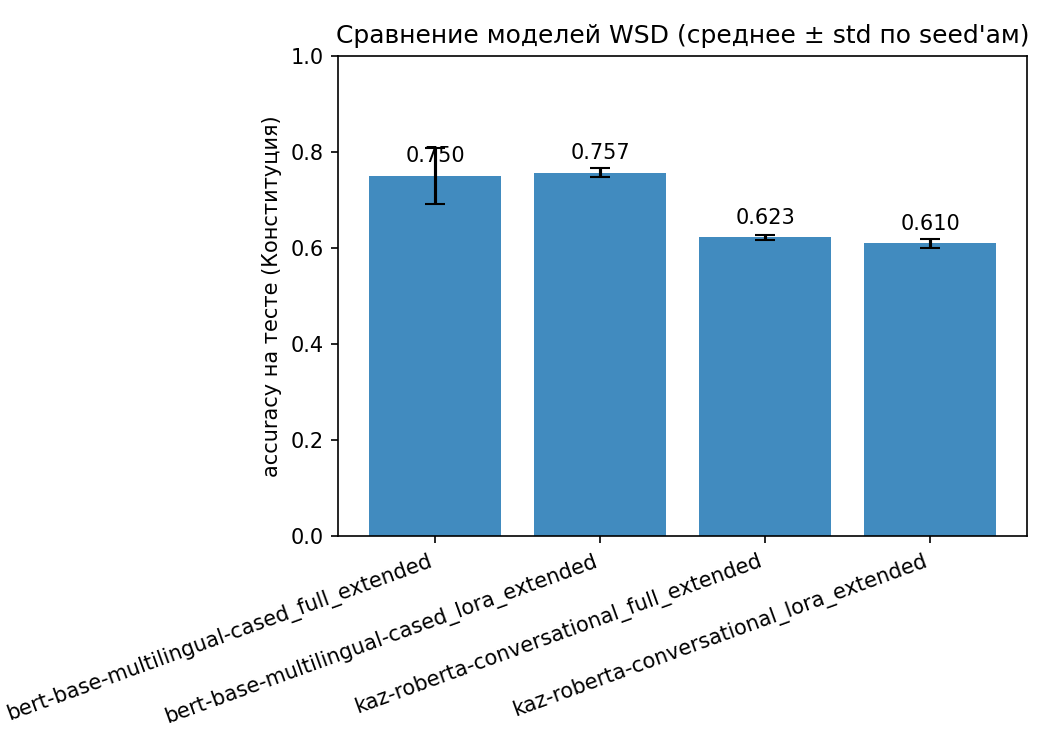

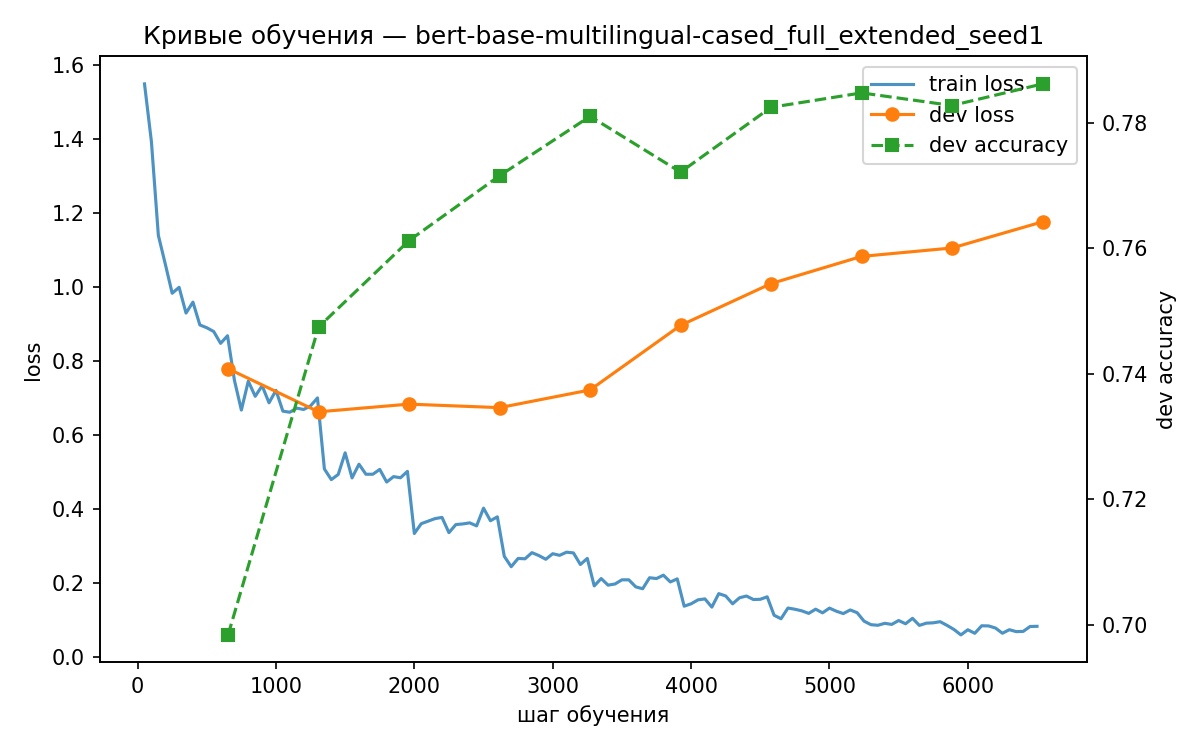

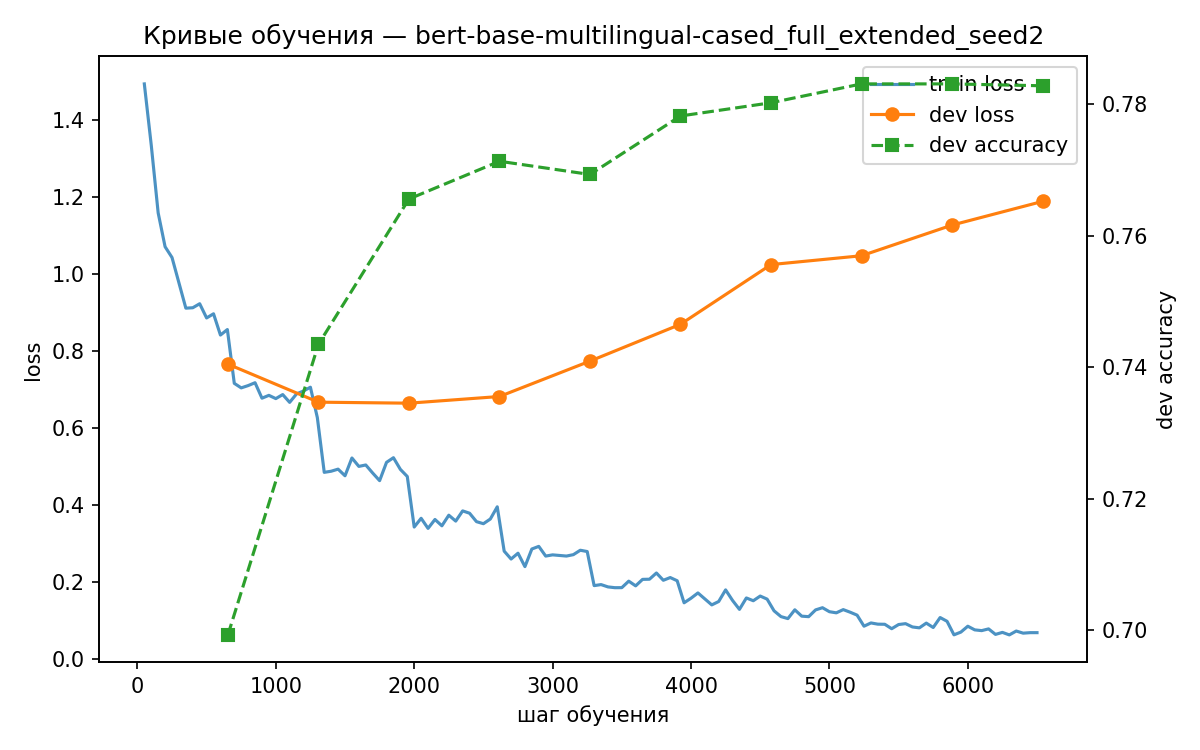

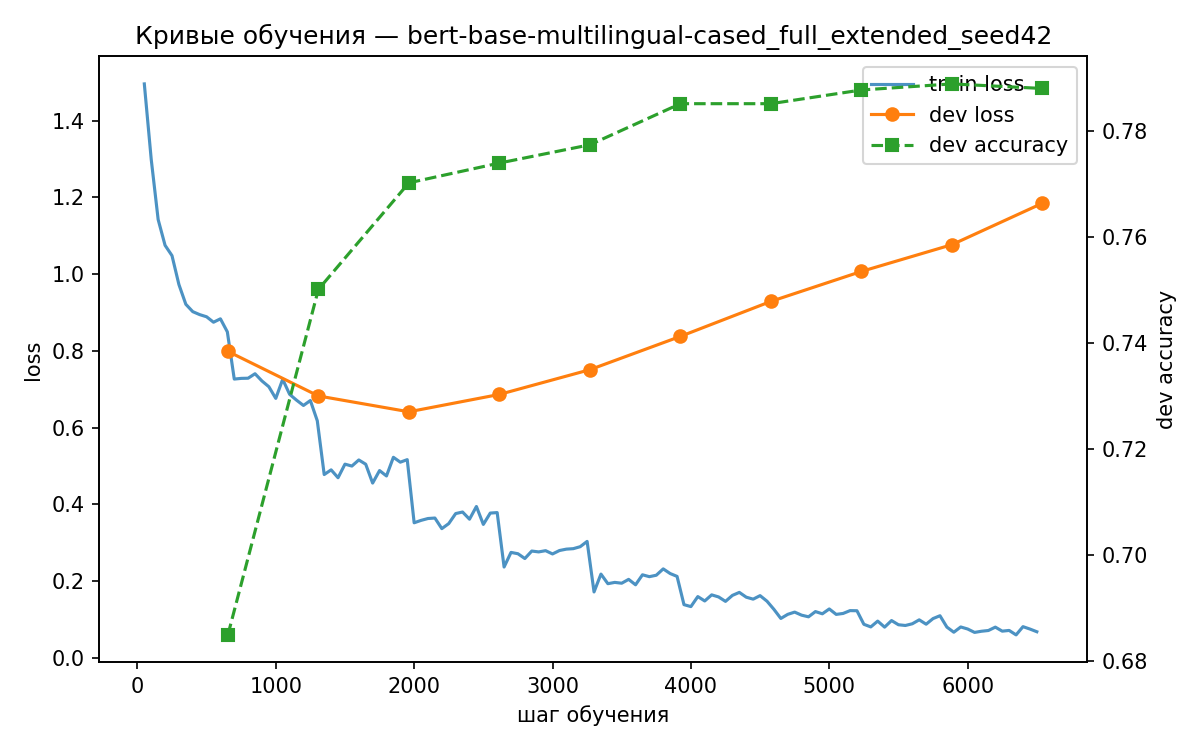

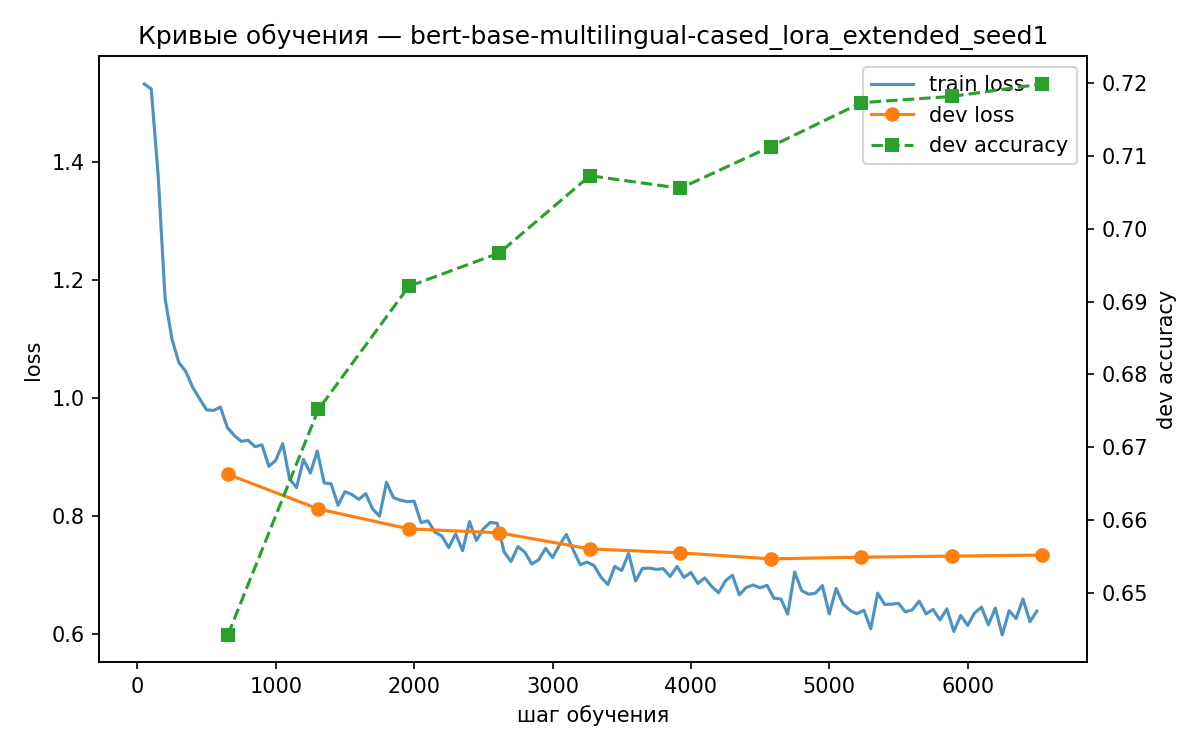

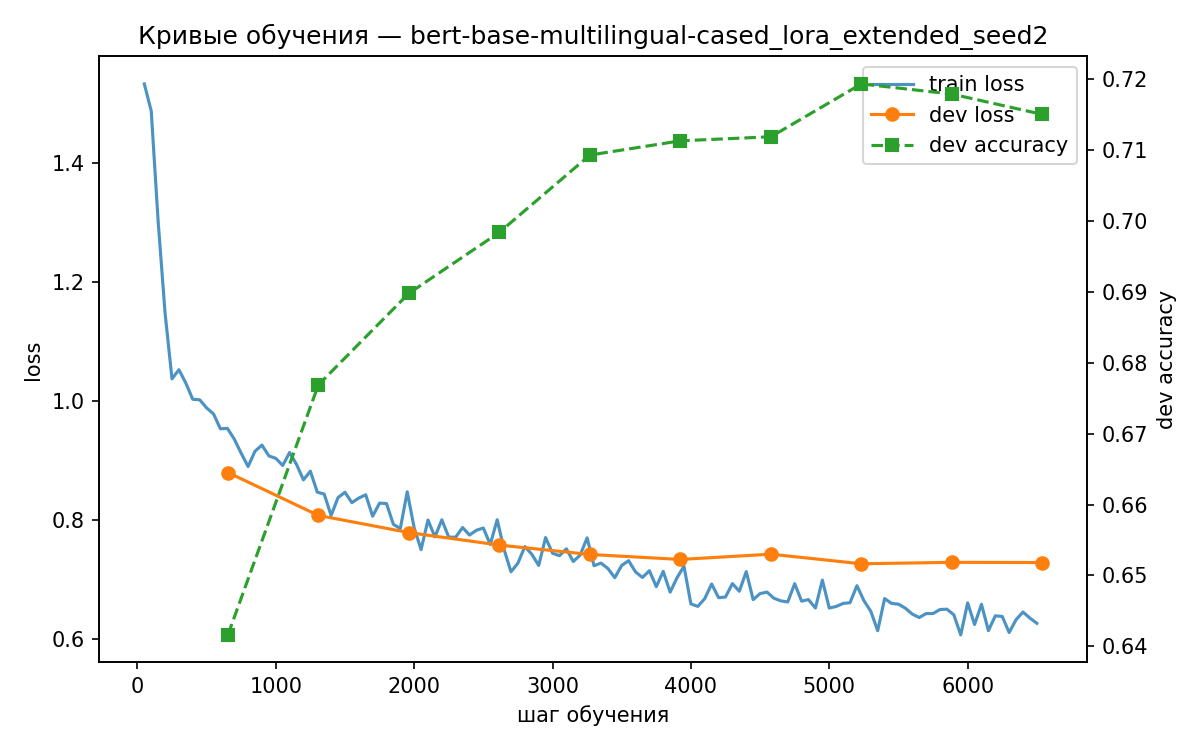

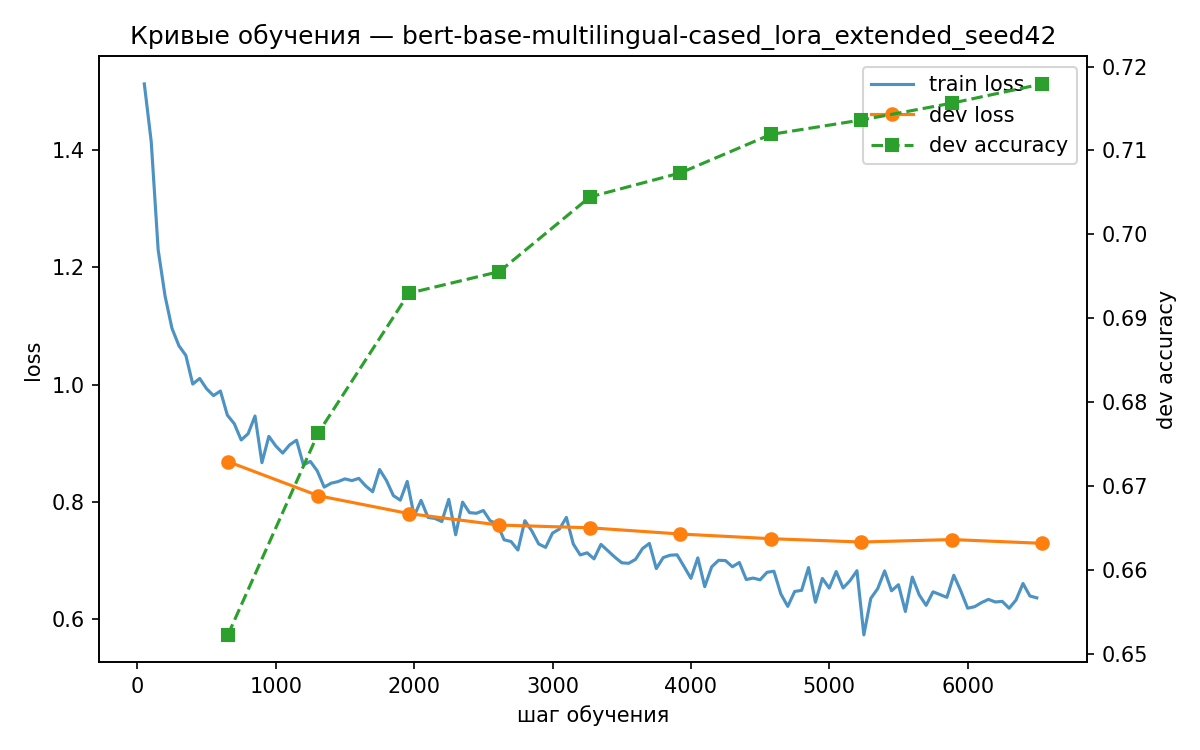

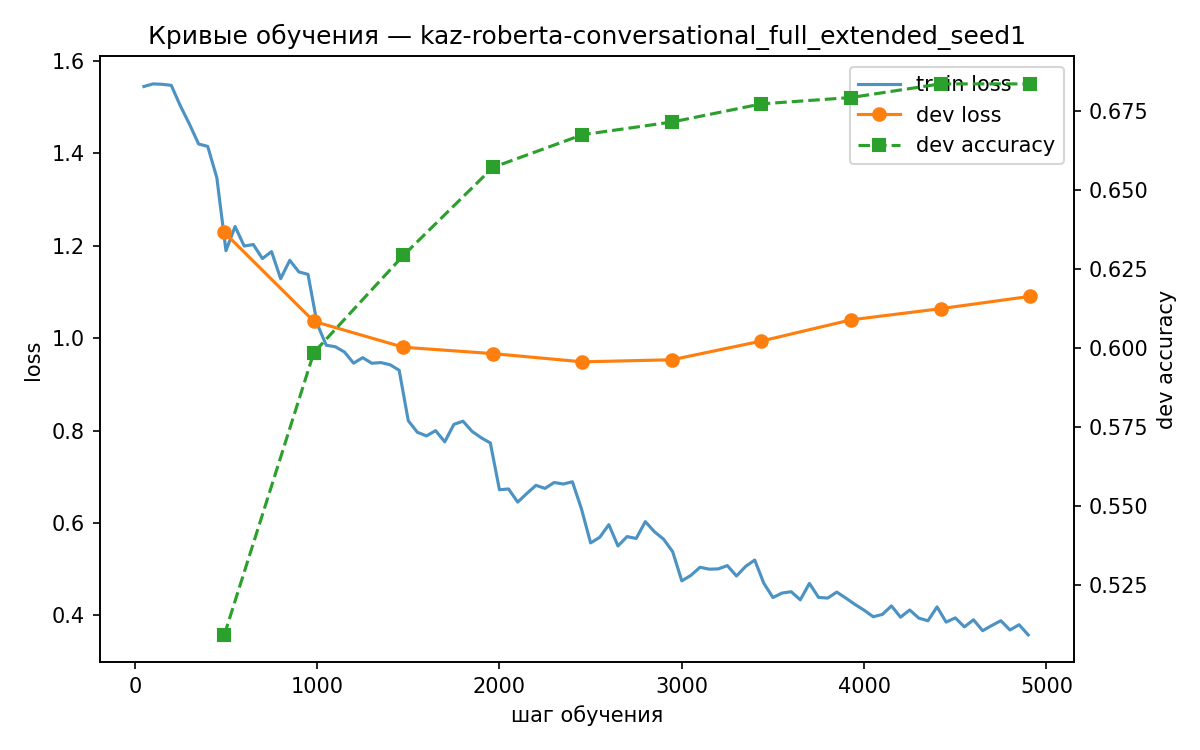

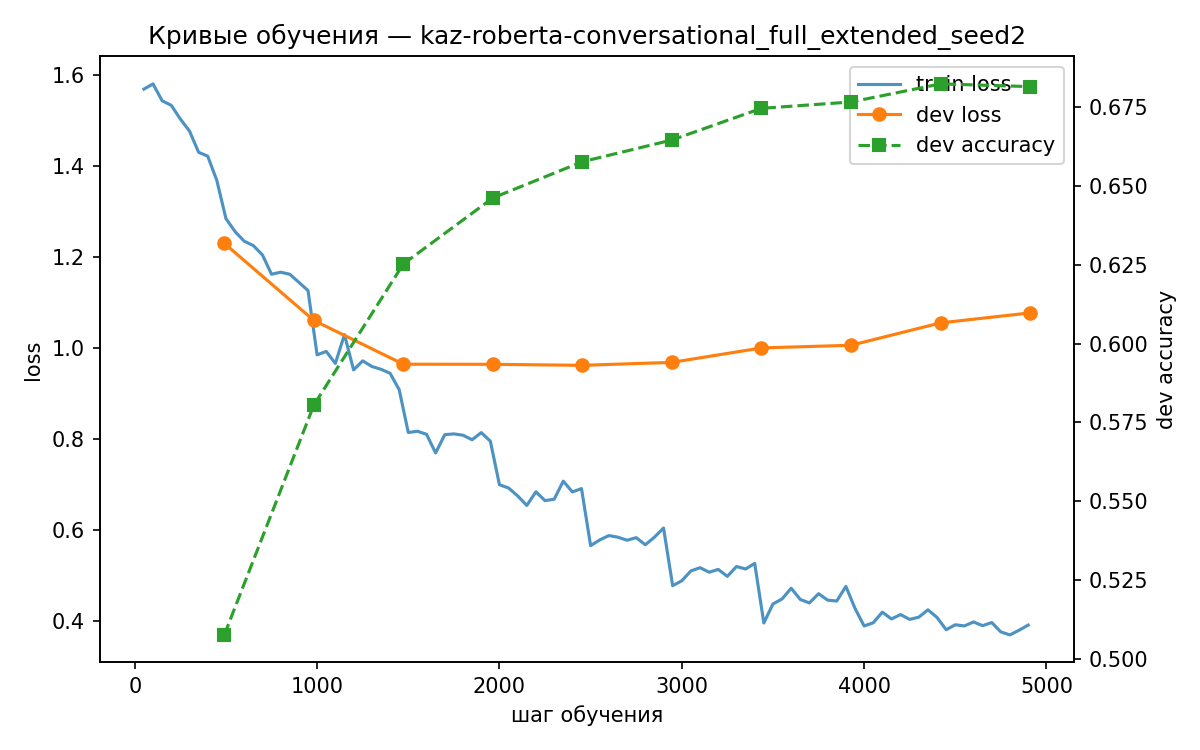

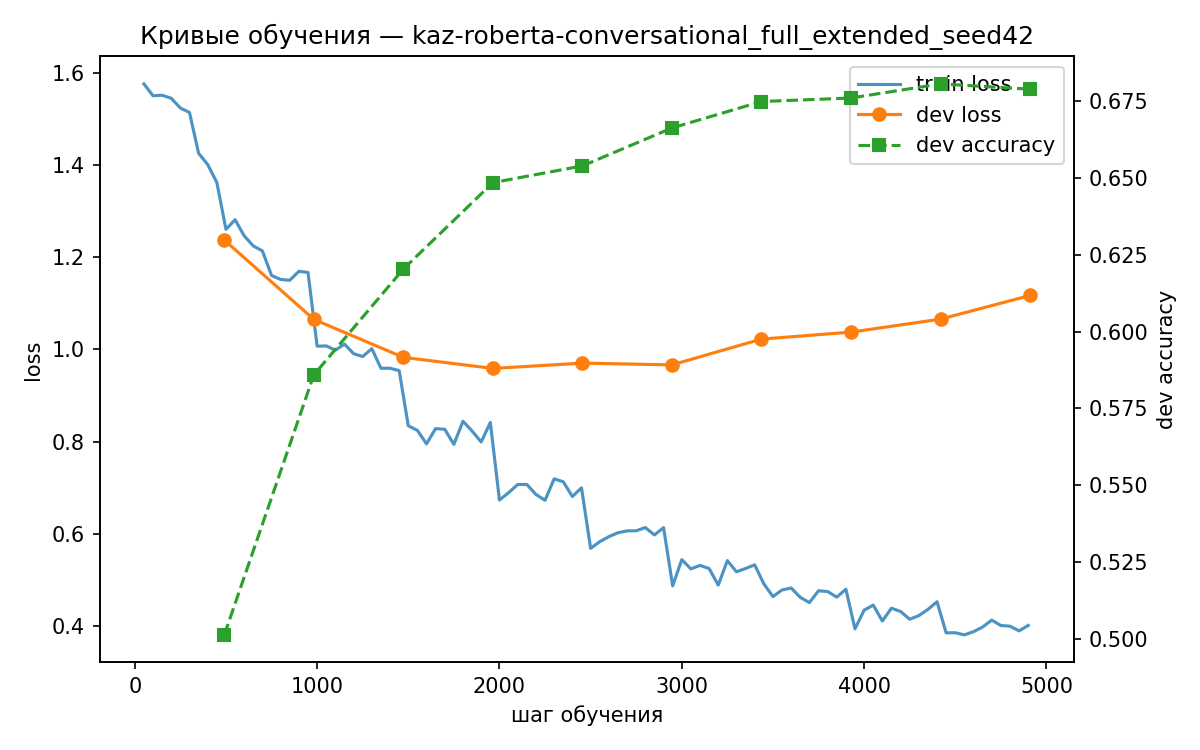

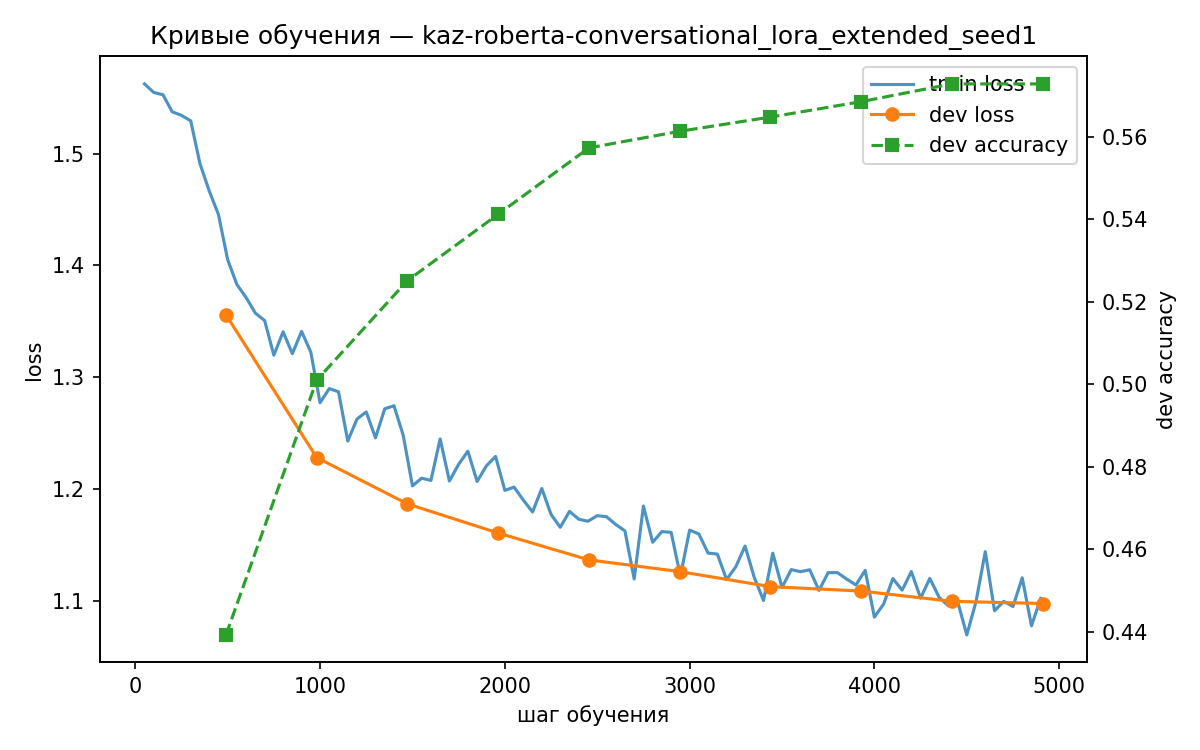

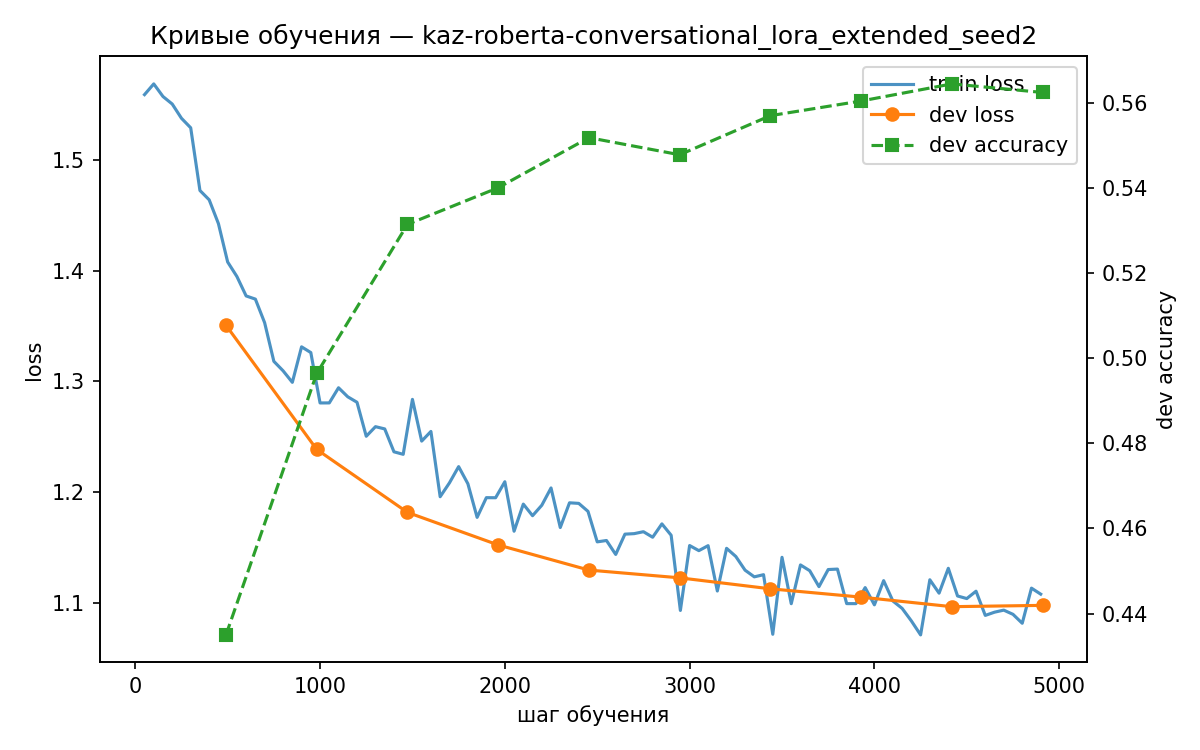

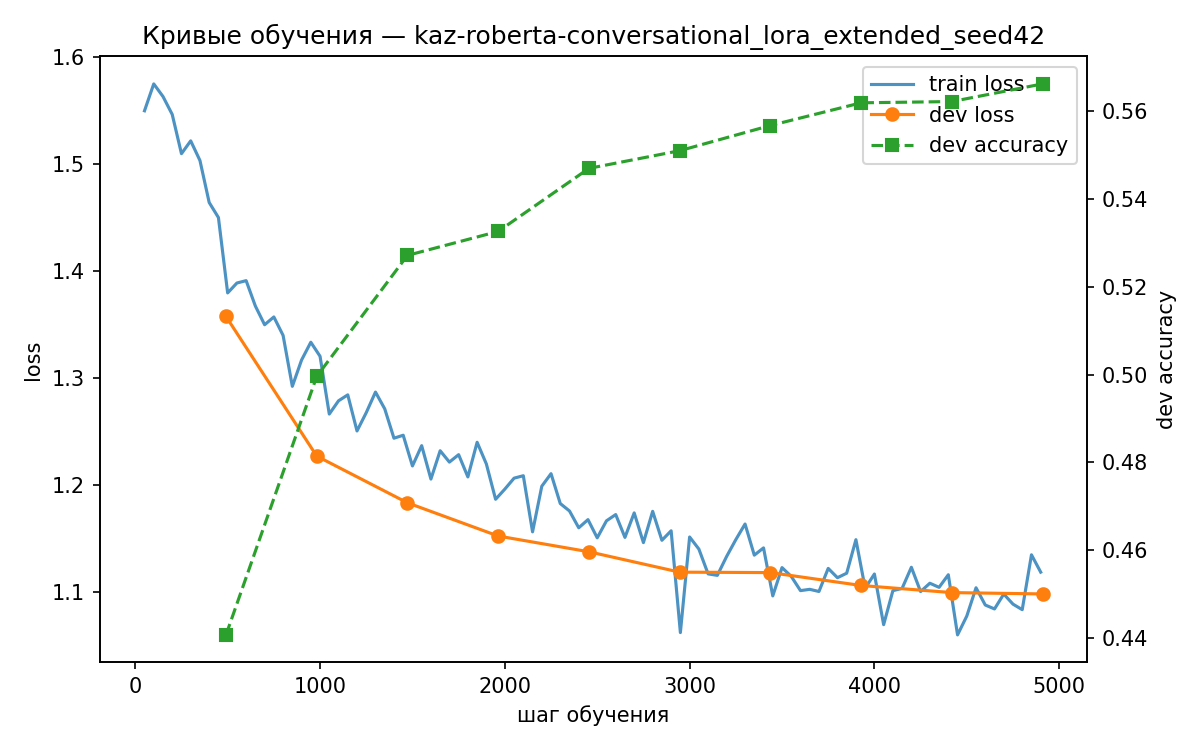

In [21]:
subprocess.run(['python', 'plot_results.py'], check=True)

from IPython.display import Image, display
if os.path.exists('runs/results_bar.png'):
    display(Image('runs/results_bar.png'))
for p in sorted(glob.glob('runs/*_seed*/loss_curve.png')):
    display(Image(p))

## Результаты

- `runs/<model>_<mode>_seed<n>/` — веса, история лоссов, кривая обучения по прогону.
- `runs/evaluation.json` — accuracy + bootstrap 95% CI по прогонам и агрегат по seed'ам.
- `runs/results_bar.png` — сравнение моделей с доверительными интервалами.

Папку `runs/` стоит сохранить (она в Drive, если проект в Drive).

In [22]:
!tar cf /content/runs_meta.tar --exclude='*/hf_out' --exclude='*/model.pt' \
  --exclude='*/model' runs/